# Preparation

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

## Import Dataset

In [2]:
House_price_df=pd.read_csv('/kaggle/input/house-price-prediction-challenge/train.csv')
House_price_df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


# EDA (Exploratory Data Analysis)

## Data Understanding

In [3]:
House_price_df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [4]:
House_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB


In [5]:
House_price_df.isna().sum()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

In [6]:
Data_duplicate=House_price_df.duplicated().sum()
print("Total of Duplicate Data:", Data_duplicate)

Total of Duplicate Data: 401


In [7]:
row, col=House_price_df.shape
print("Row of Dataframe:",row)
print("Column of Dataframe:",col)

Row of Dataframe: 29451
Column of Dataframe: 12


## Visualization

### Visualization of Types of Sellers of Houses

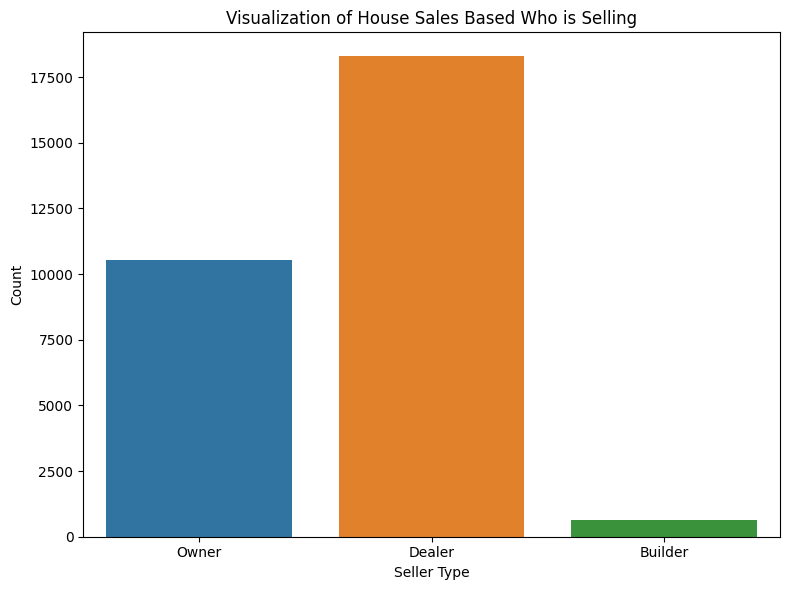

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(data=House_price_df, x='POSTED_BY')
plt.xlabel('Seller Type')
plt.ylabel('Count')
plt.title('Visualization of House Sales Based Who is Selling')
plt.tight_layout()
plt.show()

### Visualization of Status of Houses Under Construction 

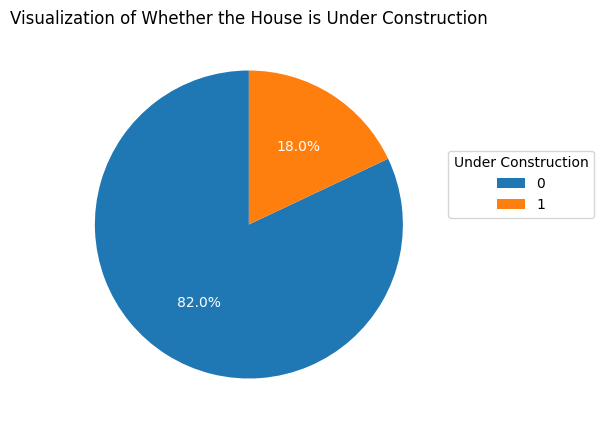

In [9]:
count_under_construction=House_price_df['UNDER_CONSTRUCTION'].value_counts()
plt.figure(figsize=(5,5))
wedges, texts, autotexts=plt.pie(
    count_under_construction.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)
plt.title('Visualization of Whether the House is Under Construction')
plt.legend(wedges, count_under_construction.index, title='Under Construction',loc='lower left', bbox_to_anchor=(1,0.5))
plt.show()

### Visualization of RERA Approval on Houses for Sale

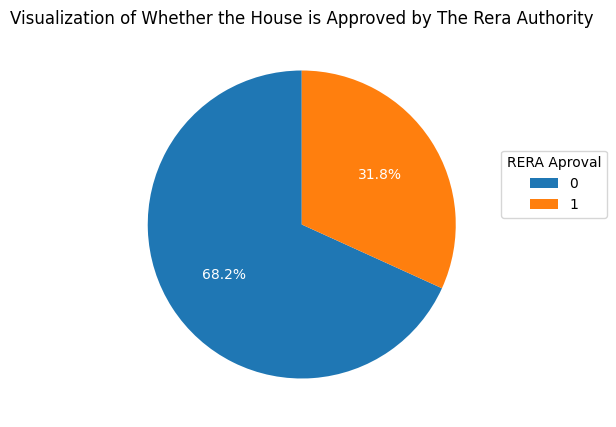

In [10]:
count_rera=House_price_df['RERA'].value_counts()
plt.figure(figsize=(5,5))
wedges, textx, autotexts=plt.pie(
    count_rera.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,
    textprops={'color':'white'}
)
plt.title('Visualization of Whether the House is Approved by The Rera Authority')
plt.legend(wedges, count_rera.index, title='RERA Aproval', loc='lower left',bbox_to_anchor=(1,0.5))
plt.show()

### Visualization of Number of Rooms in Houses Sales

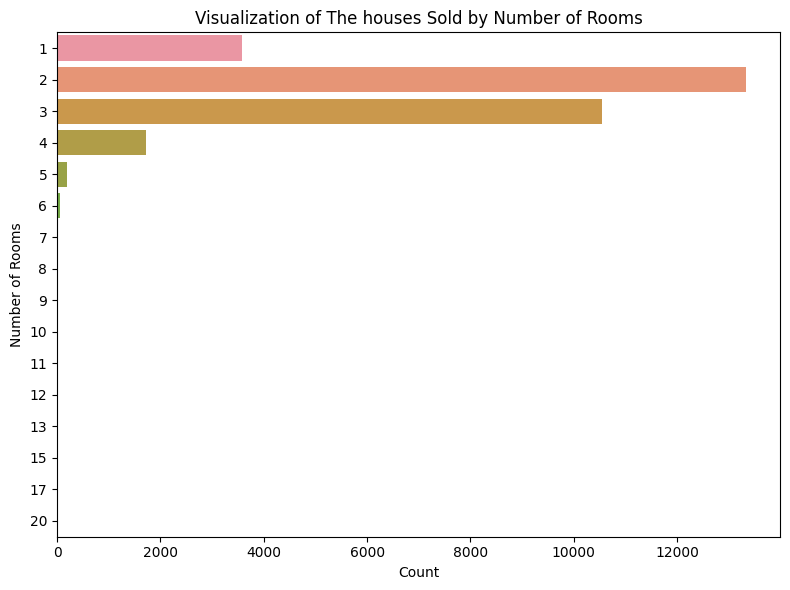

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(data=House_price_df, y='BHK_NO.')
plt.xlabel('Count')
plt.ylabel('Number of Rooms')
plt.title('Visualization of The houses Sold by Number of Rooms')
plt.tight_layout()
plt.show()

### Visualization of Property Type in Houses Sales

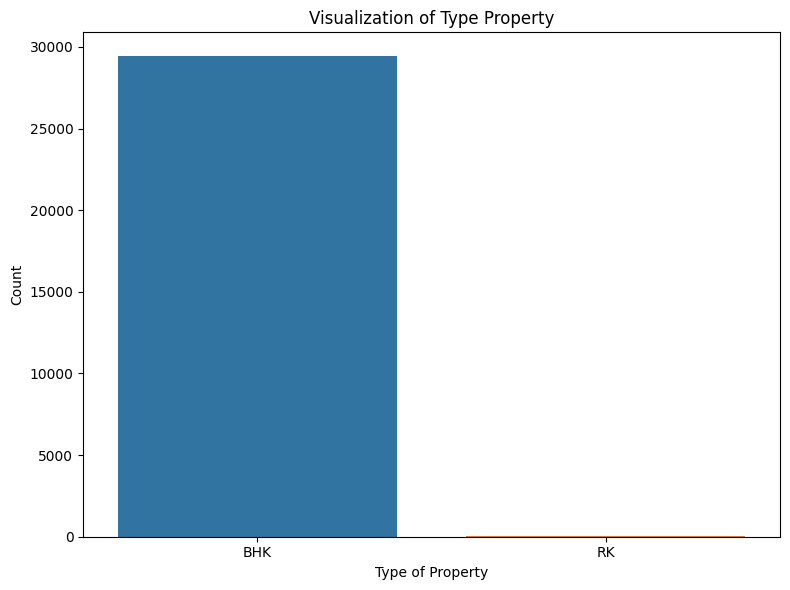

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(data=House_price_df, x='BHK_OR_RK')
plt.title('Visualization of Type Property')
plt.xlabel('Type of Property')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Visualization of Ready To Move Status in House Sales

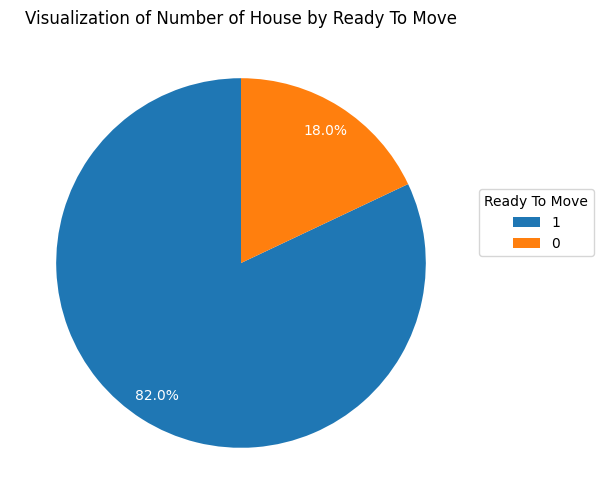

In [13]:
count_ready=House_price_df['READY_TO_MOVE'].value_counts()
plt.figure(figsize=(8,6))
wedges, texts, autotexts=plt.pie(
    count_ready.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    textprops={'color':'white'}
)
plt.title('Visualization of Number of House by Ready To Move')
plt.legend(wedges, count_ready.index, title='Ready To Move',loc='lower left', bbox_to_anchor=(1,0.5))
plt.show()

### Visualization of Resale Status in Houses Sales

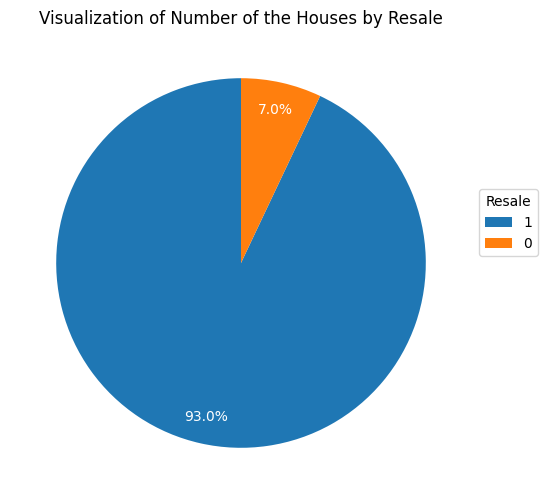

In [14]:
count_resale=House_price_df['RESALE'].value_counts()
plt.figure(figsize=(8,6))
wedges, texts, autotexts=plt.pie(
    count_resale.values,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    textprops={'color':'white'}
)
plt.title('Visualization of Number of the Houses by Resale')
plt.legend(wedges, count_resale.index, title='Resale', loc='lower left', bbox_to_anchor=(1,0.5))
plt.show()

### Distribution of Houses by Top 20 Houses

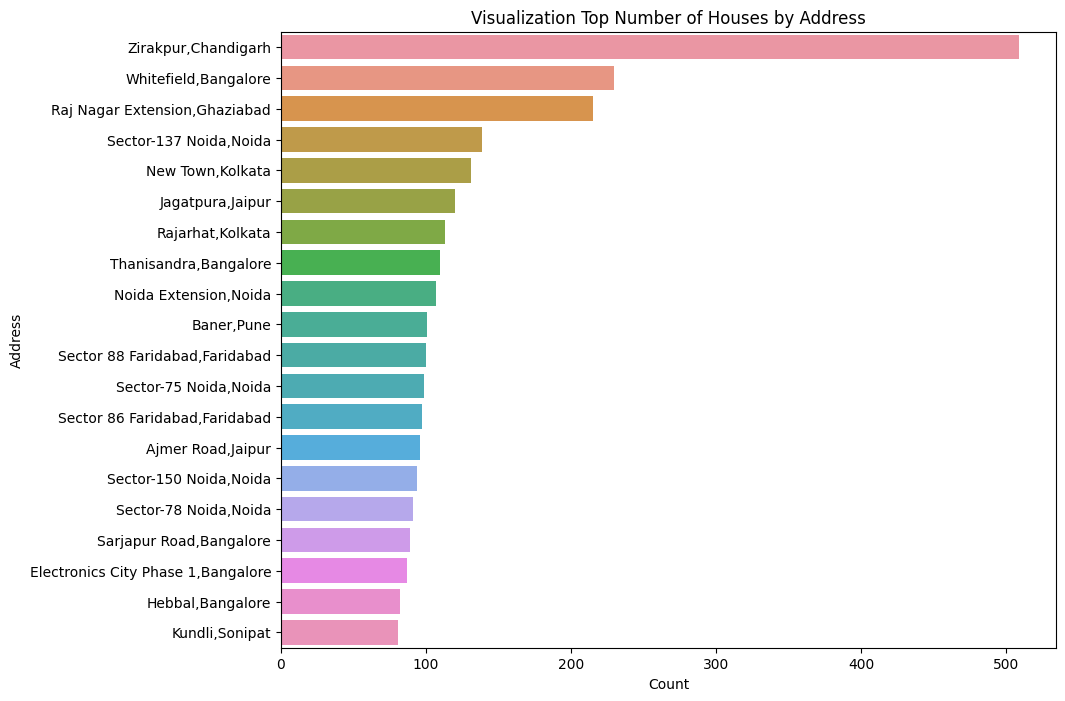

In [15]:
top_house_located=House_price_df['ADDRESS'].value_counts().head(20)
plt.figure(figsize=(10,8))
sns.barplot(y=top_house_located.index,x=top_house_located.values)
plt.xlabel('Count')
plt.ylabel('Address')
plt.title('Visualization Top Number of Houses by Address')
plt.show()

### Boxplot of Numerical Feature on House Sales

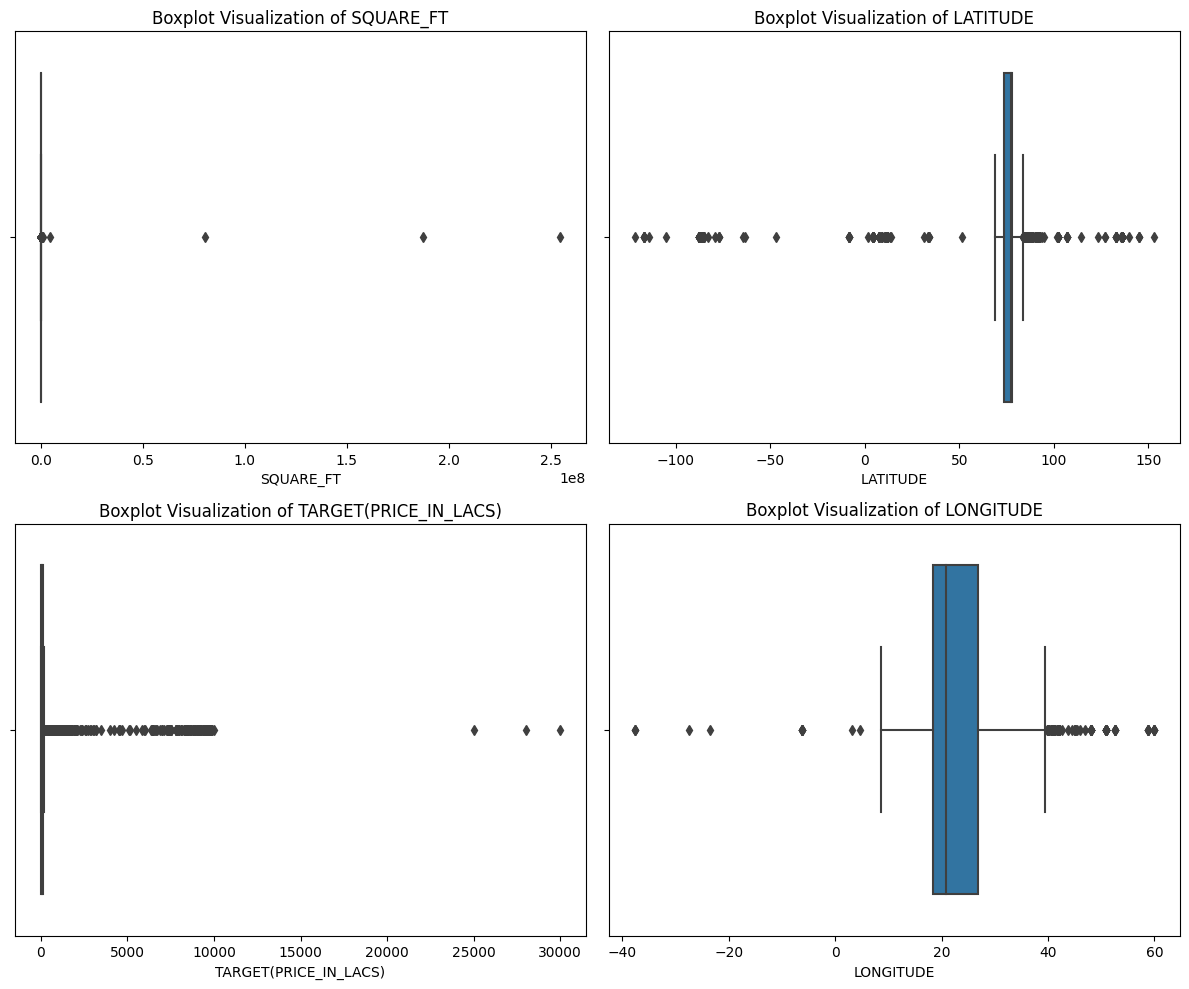

In [16]:
num_features=['SQUARE_FT','LATITUDE','TARGET(PRICE_IN_LACS)','LONGITUDE']
fig, axes=plt.subplots(2,2, figsize=(12,10))
axes=axes.flatten()
for i, feature in enumerate(num_features):
    sns.boxplot(data=House_price_df, x=feature, ax=axes[i])
    axes[i].set_xlabel(feature)
    axes[i].set_title(f'Boxplot Visualization of {feature}')

plt.tight_layout()
plt.show()

### Histogram of Numerical Feature on House Sales

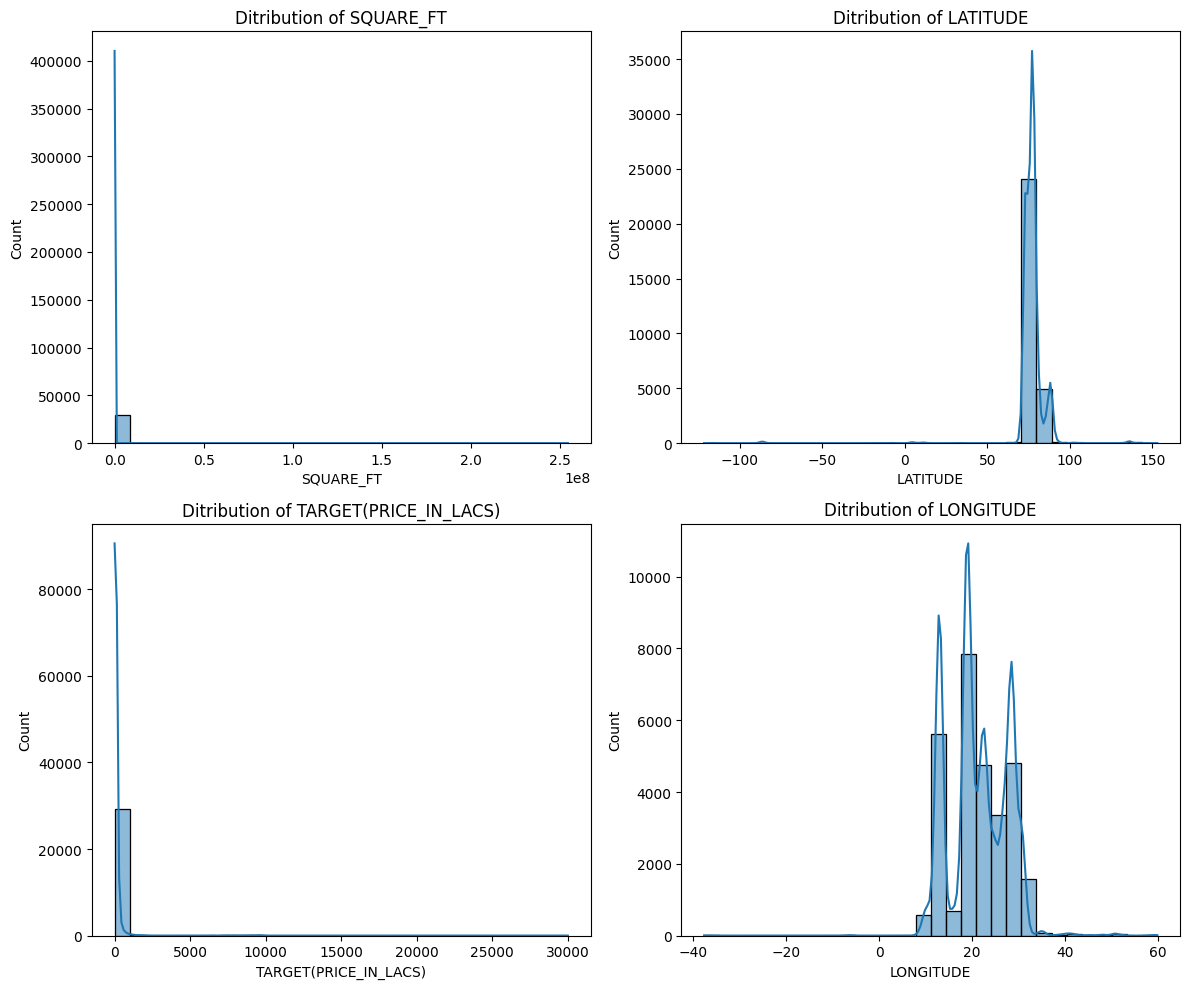

In [17]:
num_features=['SQUARE_FT','LATITUDE','TARGET(PRICE_IN_LACS)','LONGITUDE']
fig, axes=plt.subplots(2,2,figsize=(12,10))
axes=axes.flatten()
for i, feature in enumerate(num_features):
    sns.histplot(House_price_df[feature],bins=30, kde=True, edgecolor='black', ax=axes[i])
    axes[i].set_xlabel(feature)
    axes[i].set_title(f'Ditribution of {feature}')

plt.tight_layout()
plt.show()

### Visualzation of House Status by Reseller Type

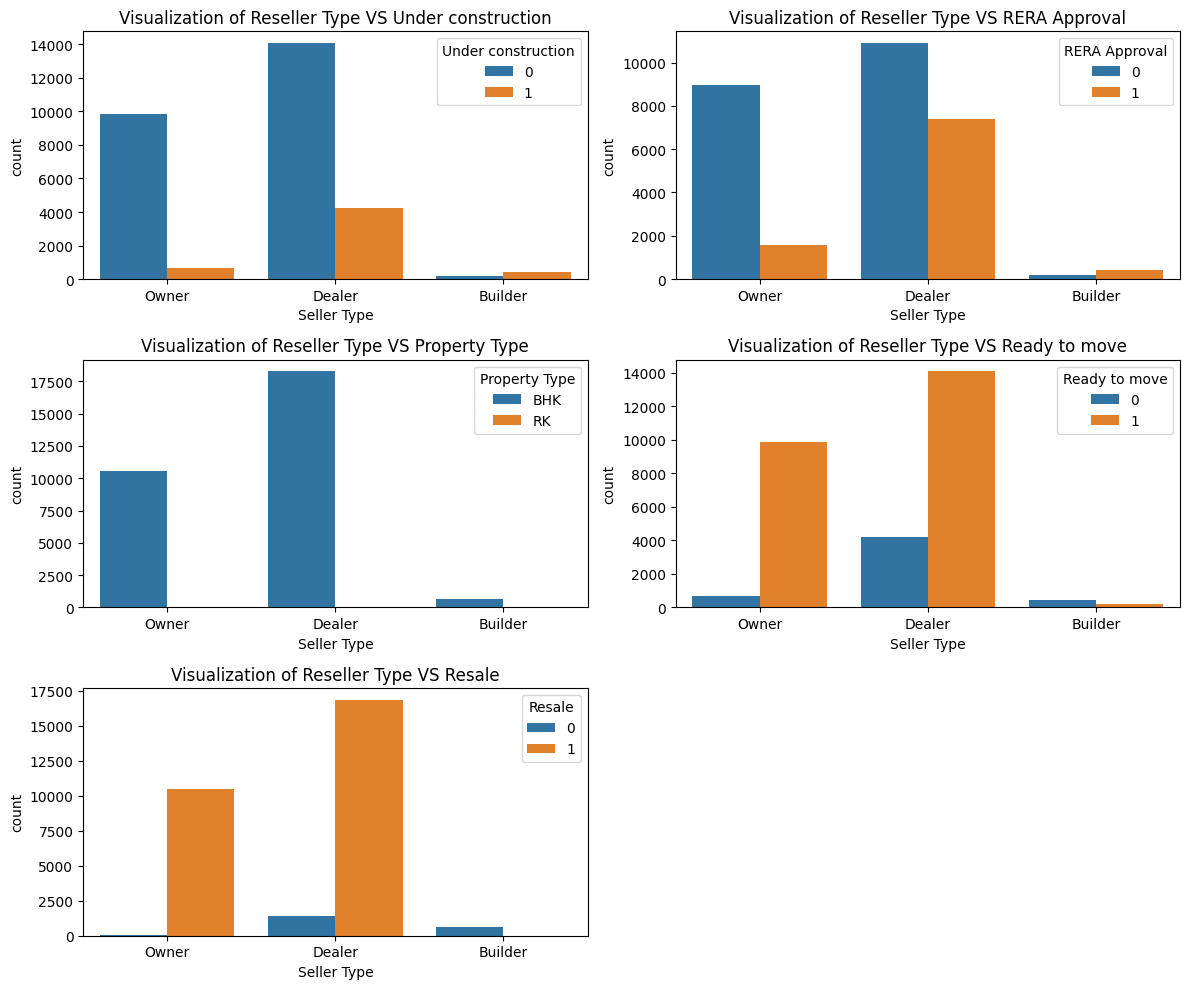

In [18]:
Attribute_of_house=['UNDER_CONSTRUCTION','RERA','BHK_OR_RK','READY_TO_MOVE','RESALE']
fig, axes=plt.subplots(3,2, figsize=(12,10))
axes=axes.flatten()
for i, col in enumerate(Attribute_of_house):
    sns.countplot(data=House_price_df, x='POSTED_BY', hue=col, ax=axes[i])
    axes[i].set_xlabel('Seller Type')
    axes[i].legend(title=col.replace('_',' ').capitalize())
    axes[i].set_title(f'Visualization of Reseller Type VS {col.replace("_"," ").capitalize()}')
    if col=='BHK_OR_RK':
        axes[i].legend(title='Property Type')
        axes[i].set_title('Visualization of Reseller Type VS Property Type')
    elif col=='RERA':
        axes[i].legend(title='RERA Approval')
        axes[i].set_title('Visualization of Reseller Type VS RERA Approval')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### Visualization of Property Category by Under Construction Status

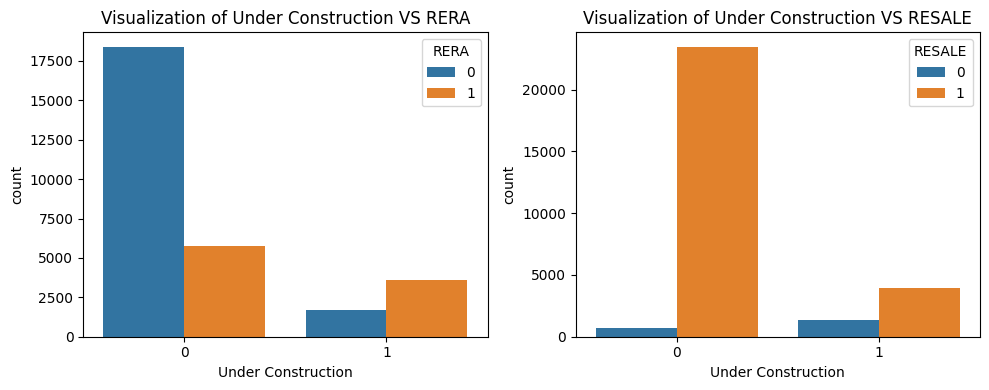

In [19]:
Attribute_of_house=['RERA','RESALE']
fig, axes=plt.subplots(1, 2 , figsize=(10,4))
axes=axes.flatten()
for i, col in enumerate(Attribute_of_house):
    sns.countplot(data=House_price_df, x='UNDER_CONSTRUCTION', hue=col, ax=axes[i])
    axes[i].set_xlabel('Under Construction')
    axes[i].set_title(f'Visualization of Under Construction VS {col}')

plt.tight_layout()
plt.show()

### Visualization of top 5 House's Address by Seller Type 

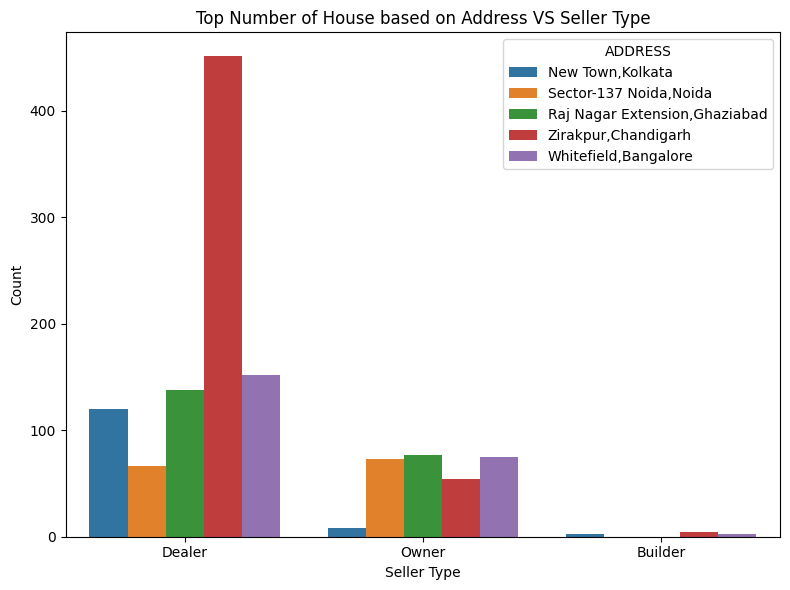

In [21]:
top_house_address=House_price_df['ADDRESS'].value_counts().head(5).index
plt.figure(figsize=(8,6))
sns.countplot(data=House_price_df[House_price_df['ADDRESS'].isin(top_house_address)], 
              x='POSTED_BY', 
              hue='ADDRESS')
plt.xlabel('Seller Type')
plt.ylabel('Count')
plt.title('Top Number of House based on Address VS Seller Type')
plt.tight_layout()

### Visualization of Top 5 Houses Address by RERA Approval

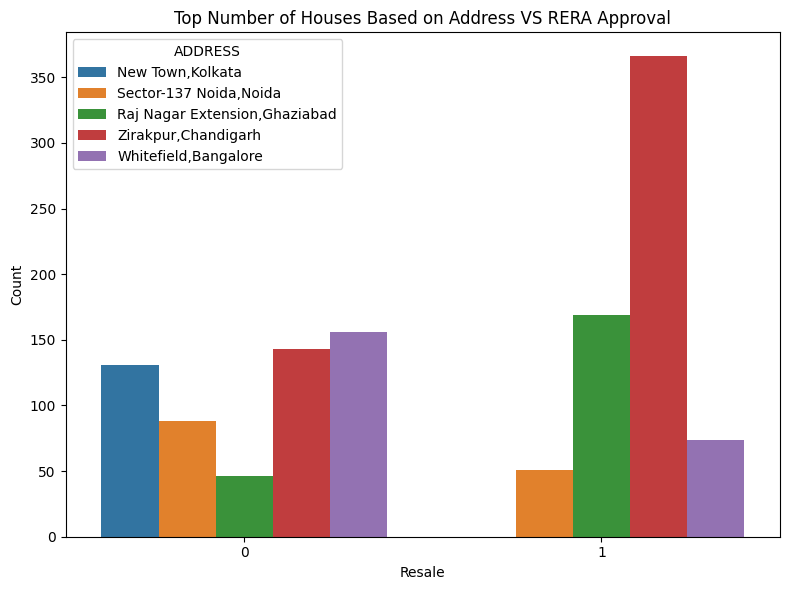

In [22]:
plt.figure(figsize=(8,6))
sns.countplot(data=House_price_df[House_price_df['ADDRESS'].isin(top_house_address)],
             x='RERA',
             hue='ADDRESS'
             )
plt.xlabel('Resale')
plt.ylabel('Count')
plt.title('Top Number of Houses Based on Address VS RERA Approval')
plt.tight_layout()
plt.show()


### Heatmap of Numerical Feature on House Sales

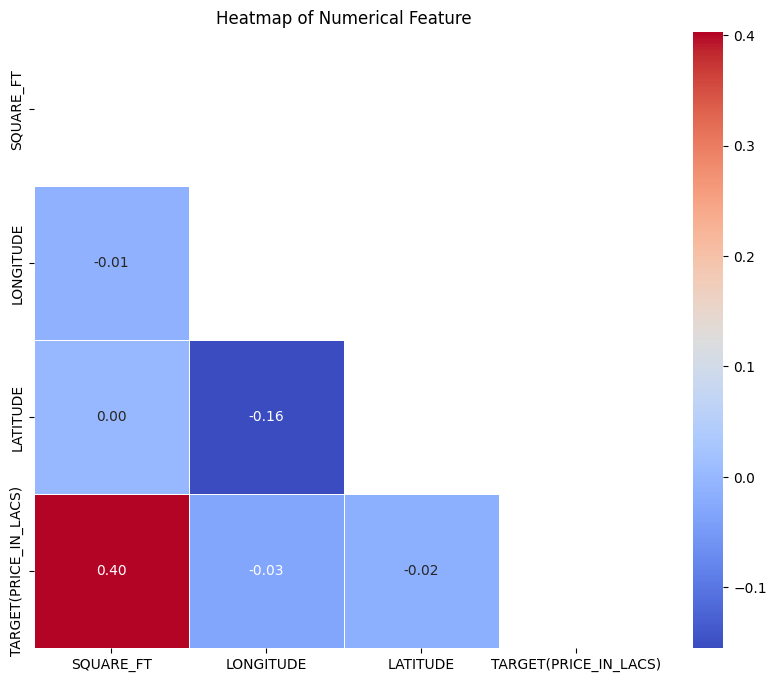

In [23]:
num_columns=House_price_df[['SQUARE_FT','LONGITUDE','LATITUDE','TARGET(PRICE_IN_LACS)']]
corr_num=num_columns.corr()
mask=np.triu(np.ones_like(corr_num,dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm',linewidths=0.5, mask=mask,fmt='.2f')
plt.title('Heatmap of Numerical Feature')
plt.show()

# Preprocessing

## Drop Duplicate Data

In [24]:
House_price_df=House_price_df.drop_duplicates()

## Normalization

In [25]:
cols_to_scale=['LONGITUDE', 'LATITUDE', 'SQUARE_FT']

scaler=StandardScaler()
scaler.fit(House_price_df[cols_to_scale])
House_price_df[cols_to_scale]=scaler.transform(House_price_df[cols_to_scale])

## Encode

In [26]:
cols_to_encode=['POSTED_BY','BHK_OR_RK','ADDRESS']
encode=OneHotEncoder(drop='first', sparse=False, dtype=int, handle_unknown='ignore')
encode.fit(House_price_df[cols_to_encode])
encoded_data=encode.transform(House_price_df[cols_to_encode])

encode_cols=encode.get_feature_names_out(cols_to_encode)

encode_df=pd.DataFrame(encoded_data, columns=encode_cols)

House_price_df=pd.concat([House_price_df.drop(columns=cols_to_encode).reset_index(drop=True),
encode_df.reset_index(drop=True)], axis=1)

## Split Training Data and Test Data

In [27]:
X=House_price_df.drop(columns='TARGET(PRICE_IN_LACS)', axis=1)
y=House_price_df['TARGET(PRICE_IN_LACS)']

In [28]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print(f"Training Data Shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test Data Shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training Data Shape: X_train: (23240, 6909), y_train: (23240,)
Test Data Shape: X_test: (5810, 6909), y_test: (5810,)


# Modeling

## Random Forest

In [29]:
RF=RandomForestRegressor().fit(X_train, y_train)
eval_rf=RF.predict(X_test)

mae_rf=round(mean_absolute_error(y_test, eval_rf),3)
mse_rf=round(mean_squared_error(y_test, eval_rf),3)
r2_rf=round(r2_score(y_test, eval_rf),3)

In [30]:
Metrics_df=({
    "MAE":[mae_rf],
    "MSE":[mse_rf],
    "R2":[r2_rf]
})
Metrics_df=pd.DataFrame(Metrics_df, index=['Random Forest'])
Metrics_df

,MAE,MSE,R2
Random Forest,32.536,63332.382,0.884


## Decision Tree

In [31]:
DT=DecisionTreeRegressor().fit(X_train, y_train)
eval_dt=DT.predict(X_test)

mae_dt=round(mean_absolute_error(y_test, eval_dt),3)
mse_dt=round(mean_squared_error(y_test, eval_dt),3)
r2_dt=round(r2_score(y_test, eval_dt),3)

In [32]:
Metrics_df.loc['Decision Tree']=[mae_dt, mse_dt,r2_dt]
Metrics_df

,MAE,MSE,R2
Random Forest,32.536,63332.382,0.884
Decision Tree,35.668,32833.118,0.940


## Gradient Boosting

In [33]:
GBR=GradientBoostingRegressor().fit(X_train, y_train)
eval_gbr=GBR.predict(X_test)

mae_gbr=round(mean_absolute_error(y_test, eval_gbr),3)
mse_gbr=round(mean_squared_error(y_test, eval_gbr), 3)
r2_gbr=round(r2_score(y_test, eval_gbr), 3)


In [34]:
Metrics_df.loc['Gradient Boosting']=[mae_gbr, mse_gbr, r2_gbr]
Metrics_df

,MAE,MSE,R2
Random Forest,32.536,63332.382,0.884
Decision Tree,35.668,32833.118,0.940
Gradient Boosting,47.112,31274.307,0.943


## XGB Regressor

In [35]:
XGB=xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
).fit(X_train, y_train)
eval_xgb=XGB.predict(X_test)
mae_xgb=round(mean_absolute_error(y_test, eval_xgb),3)
mse_xgb=round(mean_squared_error(y_test, eval_xgb),3)
r2_xgb=round(r2_score(y_test, eval_xgb),3)


In [36]:
Metrics_df.loc['XGB Regressor']=[mae_xgb, mse_xgb, r2_xgb]
Metrics_df

,MAE,MSE,R2
Random Forest,32.536,63332.382,0.884
Decision Tree,35.668,32833.118,0.940
Gradient Boosting,47.112,31274.307,0.943
XGB Regressor,51.255,173391.435,0.683


# Model Testing

## House Price Testing

In [37]:
def predict_price(Posted, Under_construction, RERA, Number_of_bedroom, Property_type, Square_feet, IsReady, IsResale, Address, Longitude, Latitude):
    input_df=pd.DataFrame([{
        'POSTED_BY':Posted,
        'UNDER_CONSTRUCTION':Under_construction,
        'RERA':RERA,
        'BHK_NO.':Number_of_bedroom,
        'BHK_OR_RK':Property_type,
        'SQUARE_FT':Square_feet,
        'READY_TO_MOVE':IsReady,
        'RESALE':IsResale,
        'ADDRESS':Address,
        'LONGITUDE':Longitude,
        'LATITUDE':Latitude
    }])
    input_df[cols_to_scale]=scaler.transform(input_df[cols_to_scale])
    
    encode_input=encode.transform(input_df[cols_to_encode])
    encode_input=pd.DataFrame(encode_input, columns=encode_cols)
    final_input=pd.concat(
        [input_df.drop(columns=cols_to_encode).reset_index(drop=True),
         encode_input.reset_index(drop=True)
        ],
        axis=1
    )
    
    predicted_price=GBR.predict(final_input)
    return predicted_price[0]

price=predict_price(
    Posted='Dealer', 
    Under_construction=0, 
    RERA=1, 
    Number_of_bedroom=5,
    Property_type='BHK',
    Square_feet=5000, 
    IsReady=1, IsResale=1, 
    Address='Jigani,Bangalore',
    Longitude=12.778033, 
    Latitude=77.632191
)

print(f"House Price Prediction:{price:.2f}")

House Price Prediction:564.04


## Import Test Data

In [38]:
House_test=pd.read_csv('/kaggle/input/house-price-prediction-challenge/test.csv')
House_test.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
0,Owner,0,0,1,BHK,545.171340,1,1,"Kamrej,Surat",21.262000,73.047700
1,Dealer,1,1,2,BHK,800.000000,0,0,"Panvel,Lalitpur",18.966114,73.148278
2,Dealer,0,0,2,BHK,1257.096513,1,1,"New Town,Kolkata",22.592200,88.484911
3,Dealer,0,0,3,BHK,1400.329489,1,1,"Kalwar Road,Jaipur",26.988300,75.584600
4,Owner,0,0,1,BHK,430.477830,1,1,"Mai Mandir,Nadiad",22.700000,72.870000


## Data Test Preprocessing

In [39]:
House_test[cols_to_scale]=scaler.transform(House_test[cols_to_scale])

test_encode=encode.transform(House_test[cols_to_encode])
test_encode=pd.DataFrame(test_encode, columns=encode_cols)

final_test=pd.concat(
    [House_test.drop(columns=cols_to_encode).reset_index(drop=True),
    test_encode.reset_index(drop=True)],
    axis=1
)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:202: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## House Price Prediction

In [40]:
House_price_prediction=GBR.predict(final_test)

In [41]:
House_price_prediction=pd.DataFrame(House_price_prediction, columns=['Price'])
House_price_prediction.head()

,Price
0,42.708698
1,69.524727
2,62.337777
3,72.319041
4,61.226440
